# Joint GLM-Neural Network for Frequency-Severity Insurance Modeling
### Results Notebook

**Paper:** *A Joint GLM-Neural Network for Frequency-Severity Modeling: Empirical Evaluation on French Motor Insurance Data*  
**Authors:** Fidha Faisal, Dr. Andres Barajas Paz, Dr. Nasreddine Megrez - Heriot-Watt University (2026)

---

This notebook reproduces all results, tables, and figures from the paper. Run cells in order. Make sure `main.py` has been run first so that `model_4b.pth` exists.

**Run order:**
1. `python main.py` (trains all models)
2. `python shap_analysis.py` (generates SHAP figures)
3. Open this notebook to view results

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.formula.api as smf
import statsmodels.api as sm

from models import SharedTrunkModel
from utils import to_log_sev, from_log_sev, recalibrate

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Dataset

We use the **freMTPL2** French Motor Third-Party Liability dataset (677,991 policies). See `data/README.md` for download instructions.

In [4]:
df_freq = pd.read_csv('data/freMTPL2freq.csv')
df_sev  = pd.read_csv('data/freMTPL2sev.csv')

sev_agg = df_sev.groupby('IDpol', as_index=False).agg(
    TotalClaimAmount=('ClaimAmount', 'sum'),
    NumClaims_sev=('ClaimAmount', 'count')
)
df = pd.merge(df_freq, sev_agg, on='IDpol', how='left')
df['TotalClaimAmount'] = df['TotalClaimAmount'].fillna(0)
df['ClaimNb']          = df['ClaimNb'].fillna(0).astype(int)

mask_claims = df['ClaimNb'] > 0
df['Severity_per_claim'] = 0.0
df.loc[mask_claims, 'Severity_per_claim'] = (
    df.loc[mask_claims, 'TotalClaimAmount'] / df.loc[mask_claims, 'ClaimNb']
)
df['ActualTotalClaim'] = df['TotalClaimAmount']

print(f'Total policies:  {len(df):,}')
print(f'Claim rate:      {mask_claims.mean():.3%}')
print(f'Mean severity (claim policies): £{df.loc[mask_claims, "Severity_per_claim"].mean():,.2f}')
df[['Exposure', 'VehAge', 'DrivAge', 'BonusMalus', 'ClaimNb', 'TotalClaimAmount']].describe().round(3)

Total policies:  678,013
Claim rate:      5.024%
Mean severity (claim policies): £1,626.83


,Exposure,VehAge,DrivAge,BonusMalus,ClaimNb,TotalClaimAmount
count,678013.000,678013.000,678013.000,678013.000,678013.000,678013.000
mean,0.529,7.044,45.499,59.762,0.053,88.360
std,0.364,5.666,14.137,15.637,0.240,5822.454
min,0.003,0.000,18.000,50.000,0.000,0.000
25%,0.180,2.000,34.000,50.000,0.000,0.000
50%,0.490,6.000,44.000,50.000,0.000,0.000
75%,0.990,11.000,55.000,64.000,0.000,0.000
max,2.010,100.000,100.000,230.000,16.000,4075400.560


In [5]:
numeric_features     = ['Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']

df_dummies = pd.get_dummies(df[categorical_features], drop_first=True)
df_dummies.columns = (df_dummies.columns
    .str.replace("'", '', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False))

df_model = pd.concat(
    [df[numeric_features + ['IDpol', 'ClaimNb', 'Severity_per_claim', 'ActualTotalClaim']],
     df_dummies], axis=1)
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

features = [c for c in df_model.columns
            if c not in ['IDpol', 'ClaimNb', 'Severity_per_claim', 'ActualTotalClaim', 'Exposure_safe']]

train_pol, test_pol = train_test_split(df_model['IDpol'].unique(), test_size=0.2, random_state=SEED)
train_full = df_model[df_model['IDpol'].isin(train_pol)].reset_index(drop=True)
test       = df_model[df_model['IDpol'].isin(test_pol)].reset_index(drop=True)
train_idx, val_idx = train_test_split(range(len(train_full)), test_size=0.1, random_state=SEED)
train = train_full.iloc[train_idx].reset_index(drop=True)
val   = train_full.iloc[val_idx].reset_index(drop=True)

for df_ in [train, val, test]:
    df_['Exposure_safe'] = df_['Exposure'].replace(0, 1e-8)

test_c = test[test['ClaimNb'] > 0].copy()
print(f'Train: {len(train):,}  |  Val: {len(val):,}  |  Test: {len(test):,}')

Train: 488,169  |  Val: 54,241  |  Test: 135,603


## 2. GLM Baselines

### Table 1: Poisson GLM Coefficient Estimates

In [10]:
glm_features = [f for f in features if f != 'Exposure']
formula      = 'ClaimNb ~ ' + ' + '.join(glm_features)

glm = smf.glm(
    formula=formula, data=train,
    family=sm.families.Poisson(),
    offset=np.log(train['Exposure_safe'])
).fit()

train['glm_freq'] = glm.predict(train, offset=np.log(train['Exposure_safe']))
val['glm_freq']   = glm.predict(val,   offset=np.log(val['Exposure_safe']))
test['glm_freq']  = glm.predict(test,  offset=np.log(test['Exposure_safe']))

# Selected coefficients as reported in the paper
selected = ['Intercept', 'VehBrand_B12', 'VehBrand_B14', 'VehGas_Regular',
            'Area_D', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus']
summary = glm.summary2().tables[1]
display(summary.loc[[v for v in selected if v in summary.index]].round(3))

from sklearn.metrics import mean_squared_error, mean_absolute_error
glm_mse = mean_squared_error(test['ClaimNb'], test['glm_freq'])
glm_mae = mean_absolute_error(test['ClaimNb'], test['glm_freq'])
print(f'\nGLM Poisson: Freq MSE: {glm_mse:.6f} | MAE: {glm_mae:.6f}')

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-3.980,0.112,-35.449,0.0,-4.200,-3.760
VehPower,0.013,0.003,4.031,0.0,0.007,0.020
VehAge,-0.039,0.001,-28.474,0.0,-0.042,-0.037
DrivAge,0.007,0.000,14.609,0.0,0.006,0.008
BonusMalus,0.023,0.000,63.172,0.0,0.022,0.023



GLM Poisson: Freq MSE: 0.056333 | MAE: 0.098893


In [9]:
train_c_glm = train[train['ClaimNb'] > 0].copy()
glm_gamma   = smf.glm(
    'Severity_per_claim ~ ' + ' + '.join(glm_features),
    data=train_c_glm,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()
test_c['glm_gamma_sev'] = glm_gamma.predict(test_c)
glm_gamma_mae = mean_absolute_error(test_c['Severity_per_claim'], test_c['glm_gamma_sev'])
print(f'GLM Gamma: Sev MAE: £{glm_gamma_mae:,.2f}')

GLM Gamma: Sev MAE: £1,732.32


## 3. Model Comparison Results

### Table 2: Full Model Comparison

In [11]:
# Load pre-computed comparison table from main.py
comparison = pd.read_csv('final_model_comparison.csv')
display(comparison)

,Model,Freq_MSE,Sev_MAE,Mean_EL,Cal_Ratio,Joint_Learning,GLM_Input
0,Option 1: GLM + Separate NN,0.056333,1879.675678,87.155040,NaN,No,No
1,Option 2: GLM + Residual NN,0.055717,1842.893138,87.865020,NaN,Partial,Yes
2,Option 3: GLM + Bayesian NN,0.056333,1866.539251,92.793400,NaN,No,No
3,Option 4a: Joint NN (no GLM input),0.055811,1373.701667,20.685629,0.236,Yes,No
4,Option 4b: GLM-Informed Joint NN [FINAL],0.055874,1699.657919,89.744392,1.025,Yes,Yes


## 4. Training Dynamics and Visualisations

### Figure 1: Train vs Validation Loss | Figure 2: Severity MAE | Figure 3: Calibration

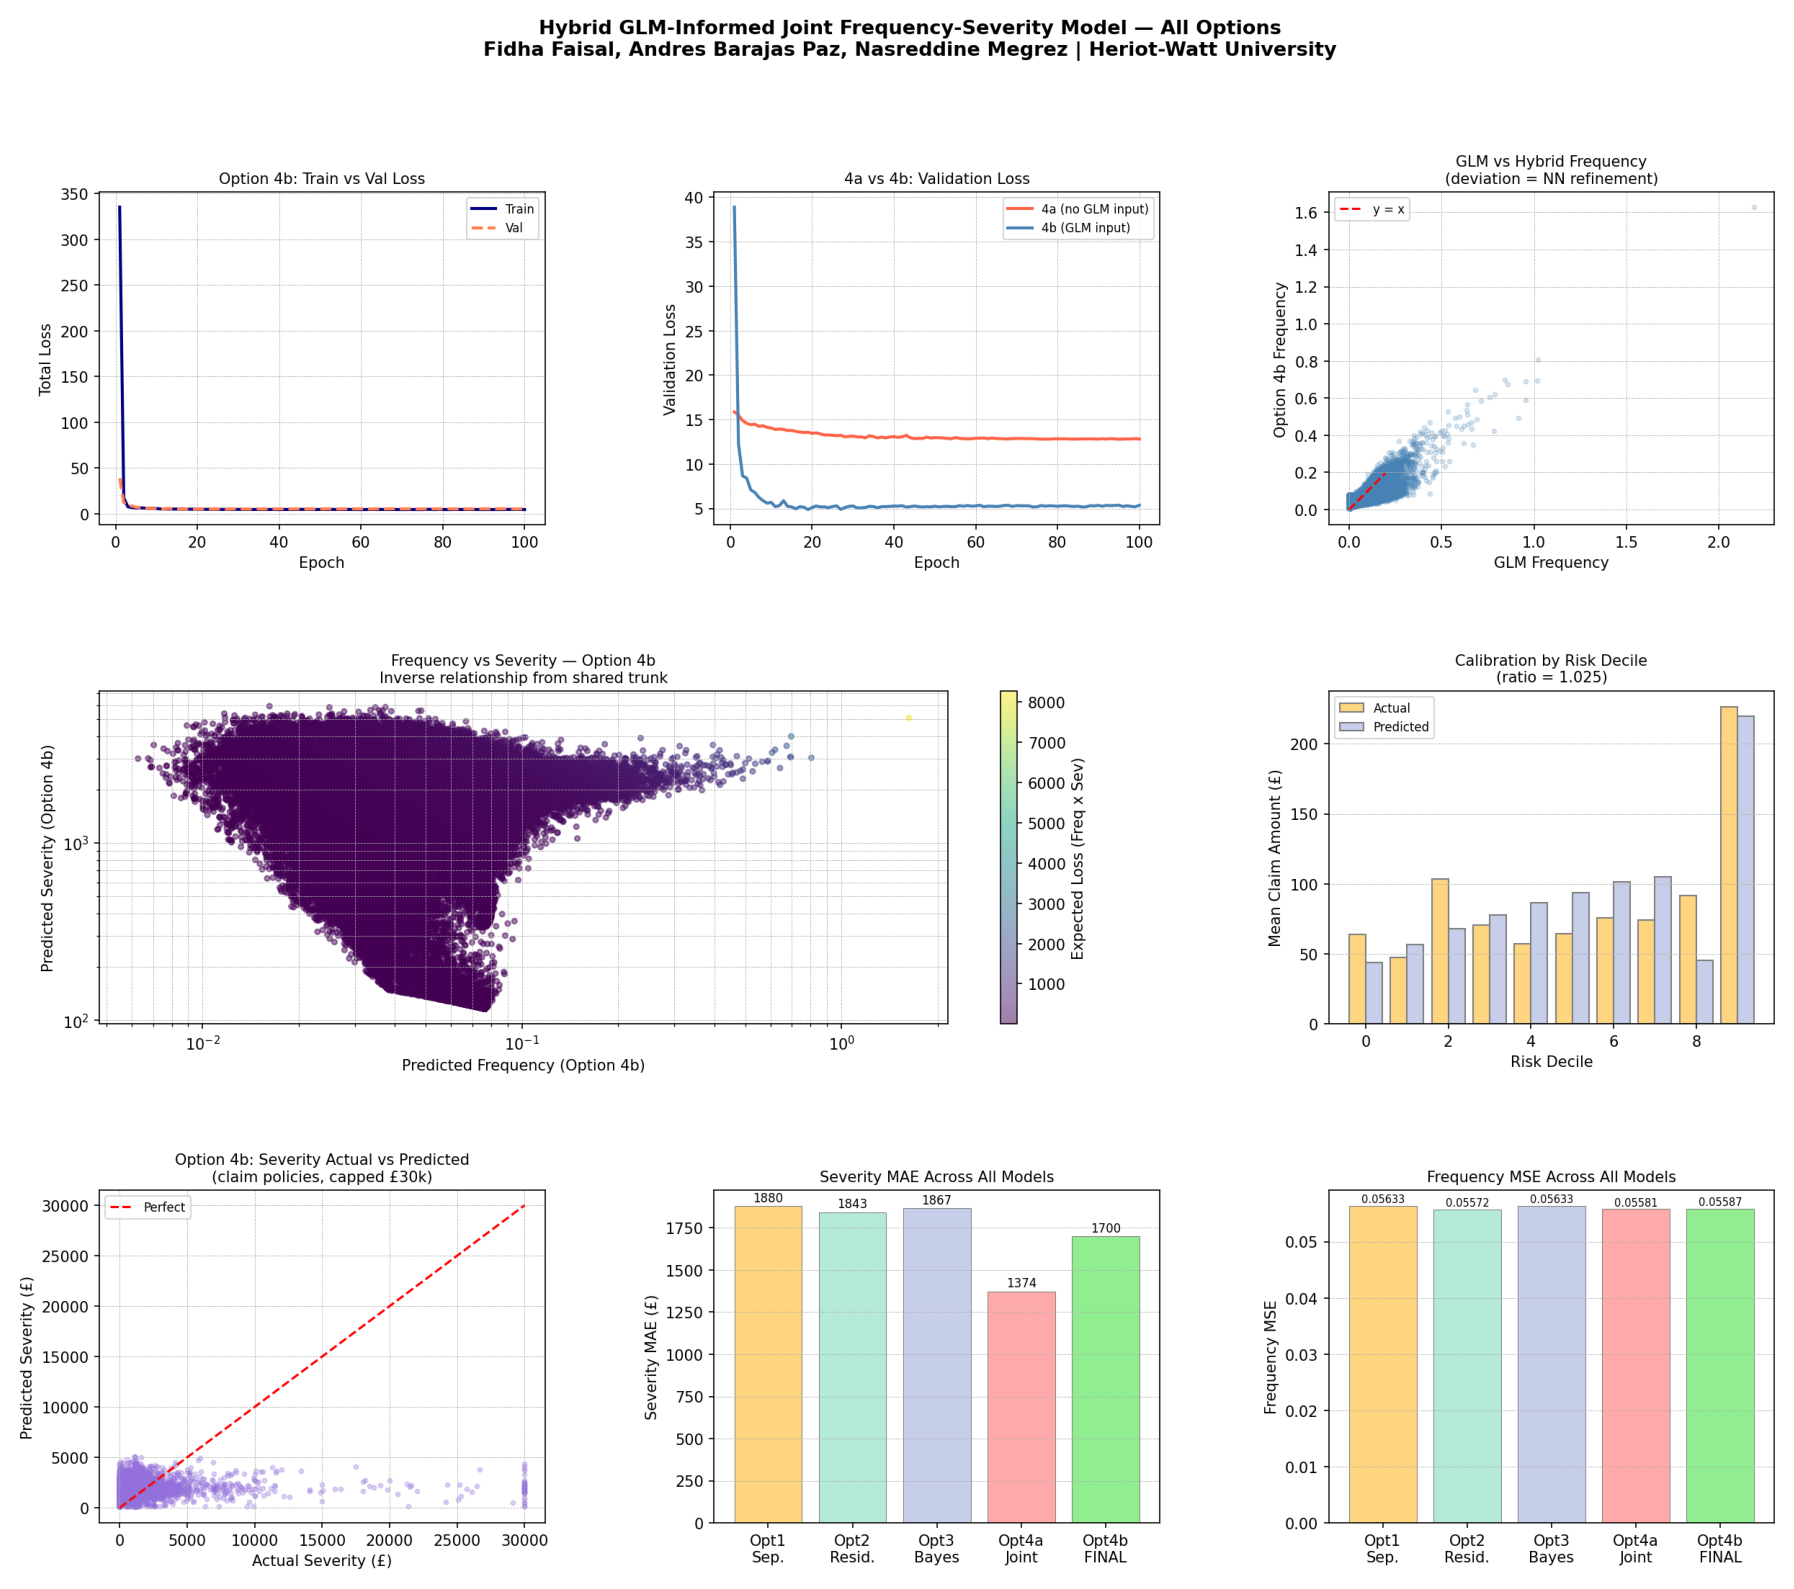

In [12]:
img = mpimg.imread('hybrid_model_results.png')
plt.figure(figsize=(20, 16))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. SHAP Interpretability

SHAP values computed using DeepExplainer (background: 100 training policies, test sample: 1,000 policies).

### Figure 5: Frequency Head Feature Importance

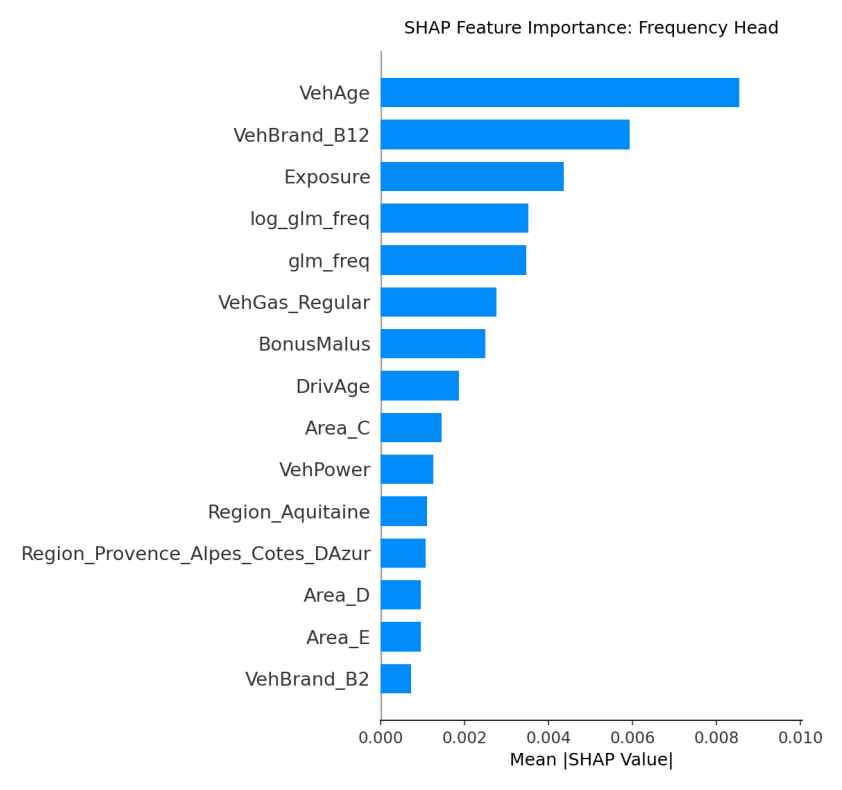

In [13]:
img_freq = mpimg.imread('shap_frequency.png')
plt.figure(figsize=(12, 8))
plt.imshow(img_freq)
plt.axis('off')
plt.tight_layout()
plt.show()

### Figure 6: Severity Head Feature Importance

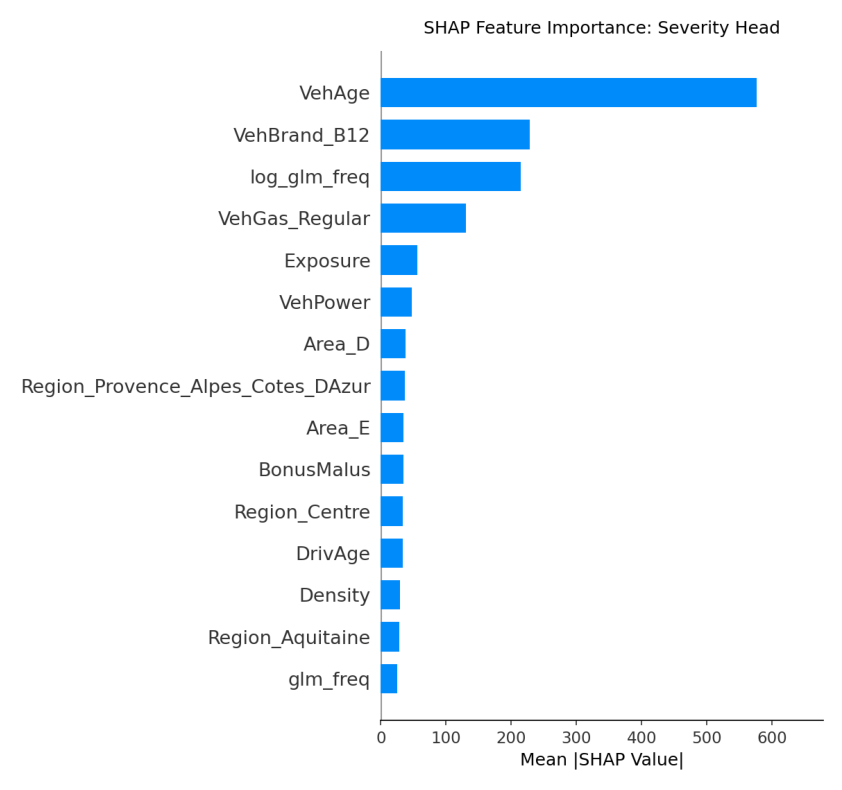

In [14]:
img_sev = mpimg.imread('shap_severity.png')
plt.figure(figsize=(12, 8))
plt.imshow(img_sev)
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Load Option 4b and Inspect Predictions

In [17]:
for df_ in [train, val, test]:
    df_['log_glm_freq'] = np.log(df_['glm_freq'] + 1e-8)
augmented_features = features + ['glm_freq', 'log_glm_freq']

scaler_aug  = StandardScaler()
X_train_aug = scaler_aug.fit_transform(train[augmented_features].values)
X_test_aug  = scaler_aug.transform(test[augmented_features].values)
X_train_aug_t = torch.tensor(X_train_aug, dtype=torch.float32)
X_test_aug_t  = torch.tensor(X_test_aug,  dtype=torch.float32)

model_4b = SharedTrunkModel(X_train_aug_t.shape[1])
model_4b.load_state_dict(torch.load('model_4b.pth'))
model_4b.eval()

with torch.no_grad():
    pf_4b, ps_4b = model_4b(X_test_aug_t)

pred_freq_4b    = pf_4b.numpy().flatten()
pred_sev_4b_raw = (F.softplus(ps_4b) + 1.0).numpy().flatten()
pred_sev_4b     = recalibrate(
    pred_sev_4b_raw,
    train[train['ClaimNb'] > 0]['Severity_per_claim'].values,
    test['ClaimNb'].values > 0
)

test['pred_4b_freq'] = pred_freq_4b
test['pred_4b_sev']  = pred_sev_4b
test['pred_4b_loss'] = pred_freq_4b * pred_sev_4b

cal_ratio = test['pred_4b_loss'].sum() / test['ActualTotalClaim'].sum()
sev_mae   = mean_absolute_error(test_c['Severity_per_claim'],
                                pred_sev_4b[test['ClaimNb'].values > 0])

print(f'Option 4b: Calibration Ratio: {cal_ratio:.4f}')
print(f'Option 4b: Severity MAE: £{sev_mae:,.2f}')
print(f'Option 4b: Mean Expected Loss: £{test["pred_4b_loss"].mean():.2f}')

Option 4b: Calibration Ratio: 1.0254
Option 4b: Severity MAE: £1,699.66
Option 4b: Mean Expected Loss: £89.74
